In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================
# Quaternion helper functions
# =========================
def normalize_quat(q):
    q = np.array(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / norm

def quat_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z])

def quat_inv(q):
    return quat_conj(q) / np.dot(q, q)

def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])


# =========================
# P-position target placeholders
# =========================
P_TARGETS = {
    "P1": {"angle": 0, "tol": 5},
    "P4": {"angle": 70, "tol": 8},
    "P6": {"angle": 20, "tol": 10},
    "P10": {"angle": 50, "tol": 8},
}


# =========================
# Haptic threshold function
# =========================
def haptic_level(error_deg):
    if error_deg < 5:
        return 0
    elif error_deg < 10:
        return 1
    else:
        return 2

In [3]:
# Step 1: Load CSV

csv_file = "TennisBall.csv"
df = pd.read_csv(csv_file)

# Clean column names just in case
df.columns = [c.strip() for c in df.columns]

required_cols = ["timestamp_ms", "qw", "qx", "qy", "qz", "gx", "gy", "gz"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Convert numeric columns
for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop bad rows
df = df.dropna(subset=required_cols).reset_index(drop=True)

if len(df) == 0:
    raise ValueError(f"No valid data rows found in {csv_file}")

# Time in seconds from start
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0

print("\nLoaded data successfully.")
print("Rows:", len(df))
print("Time range:", df["time_s"].min(), "to", df["time_s"].max(), "seconds")


Loaded data successfully.
Rows: 137
Time range: 0.0 to 4.979 seconds


In [4]:
# Step 2: Establish baseline from address

# Use low-motion region to define P1 (address)

motion_threshold = 0.5  # rad/s (tune this)

df["gyro_mag"] = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)

baseline_df = df[(df["time_s"] <= 2.0) & (df["gyro_mag"] < motion_threshold)].copy()

if len(baseline_df) == 0:
    raise ValueError("No stable baseline data found in first 2.0 seconds.")

q0 = normalize_quat([
    baseline_df["qw"].mean(),
    baseline_df["qx"].mean(),
    baseline_df["qy"].mean(),
    baseline_df["qz"].mean()
])

print("\nBaseline quaternion (P1 reference):")
print(q0)


Baseline quaternion (P1 reference):
[ 0.69138865 -0.00686651  0.72139493  0.03903761]


In [5]:
# Step 3: Compute sensor orientation relative to P1 (address)

relative_quats = []

for _, row in df.iterrows():
    q = normalize_quat([row["qw"], row["qx"], row["qy"], row["qz"]])
    q_rel = quat_mult(quat_inv(q0), q)
    q_rel = normalize_quat(q_rel)
    relative_quats.append(q_rel)

relative_quats = np.array(relative_quats)

df["rw"] = relative_quats[:, 0]
df["rx"] = relative_quats[:, 1]
df["ry"] = relative_quats[:, 2]
df["rz"] = relative_quats[:, 3]

In [6]:
# Step 4: Compute total rotation angle (relative to P1)

df["angle_rad"] = 2 * np.arccos(np.clip(df["rw"], -1.0, 1.0))
df["angle_deg"] = np.degrees(df["angle_rad"])

# Step 5: Compute angular velocity magnitude

df["gyro_mag"] = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)

print("\nAngle / gyro summary:")
print(df[["angle_deg", "gyro_mag"]].describe())

print("\nNaN check:")
print(df[["angle_deg", "gyro_mag"]].isna().sum())


Angle / gyro summary:
        angle_deg    gyro_mag
count  137.000000  137.000000
mean    72.994093    2.274151
std     70.478458    3.639465
min      7.667661    0.000000
25%      8.288974    0.016688
50%     39.590270    0.141720
75%    150.445535    4.039690
max    224.164454   20.877706

NaN check:
angle_deg    0
gyro_mag     0
dtype: int64


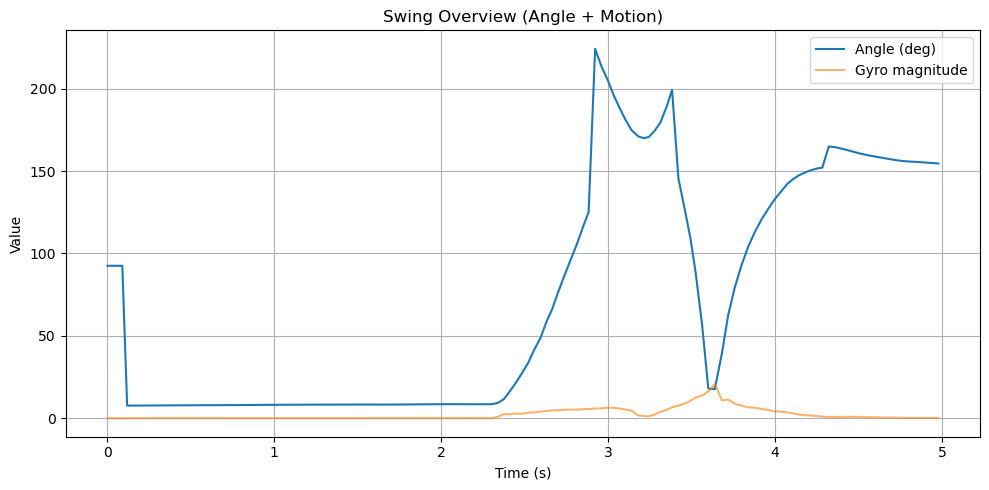

In [7]:
# Step 6: Plot full-session angle vs time

plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["angle_deg"], label="Angle (deg)")
plt.plot(df["time_s"], df["gyro_mag"], label="Gyro magnitude", alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Swing Overview (Angle + Motion)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

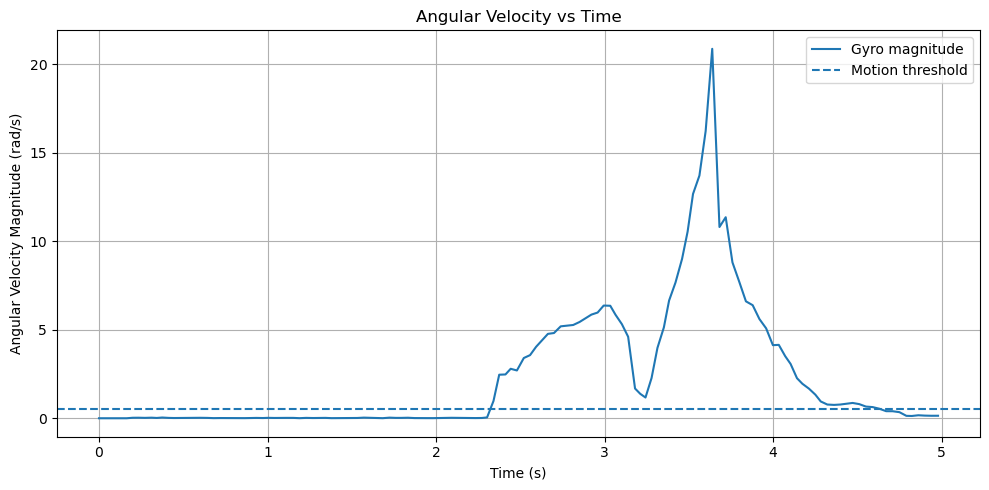

In [8]:
# Step 7: Plot full-session angular velocity vs time

motion_threshold = 0.5  # same as earlier (tune this)

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["gyro_mag"], label="Gyro magnitude")
plt.axhline(motion_threshold, linestyle="--", label="Motion threshold")

plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity Magnitude (rad/s)")
plt.title("Angular Velocity vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Step 8: Detect swing automatically

max_gyro = df["gyro_mag"].max()
print("\nMax gyro magnitude:", max_gyro)

# Motion threshold based on recorded data
start_threshold = max(0.05, 0.15 * max_gyro)
print("Using swing detection threshold:", start_threshold)

is_moving = df["gyro_mag"] > start_threshold

# Require a few consecutive moving samples to reduce noise triggers
min_run = 5
moving_indices = []

for i in range(len(df) - min_run + 1):
    if is_moving.iloc[i:i + min_run].all():
        moving_indices.append(i)

if len(moving_indices) == 0:
    raise ValueError(
        "No swing detected. Try moving more during the test or lowering the threshold."
    )

start_idx = moving_indices[0]

# Find last sustained moving region
end_candidates = []
for i in range(len(df) - min_run + 1):
    if is_moving.iloc[i:i + min_run].all():
        end_candidates.append(i + min_run - 1)

end_idx = end_candidates[-1]

# Add a little padding before/after detected movement
pad = 10
start_idx = max(0, start_idx - pad)
end_idx = min(len(df) - 1, end_idx + pad)

swing_df = df.iloc[start_idx:end_idx + 1].copy().reset_index(drop=True)

if len(swing_df) < 5:
    raise ValueError("Detected swing window is too small to analyze.")

print("\nDetected swing window:")
print("Start time:", swing_df["time_s"].iloc[0])
print("End time:", swing_df["time_s"].iloc[-1])
print("Rows:", len(swing_df))


Max gyro magnitude: 20.877705777310062
Using swing detection threshold: 3.131655866596509

Detected swing window:
Start time: 2.162
End time: 4.434
Rows: 63


In [10]:
# Step 9: Detect key P-position checkpoints

# P4 = top of backswing (approx. max rotation from address)
p4_idx = swing_df["angle_deg"].idxmax()

# P1 = first sample of swing window (or could use baseline period separately)
p1_idx = 0

# P10 = final sample of swing window
p10_idx = len(swing_df) - 1

# P6 = point after P4 where angle has dropped toward impact zone
# Approximate as the first point after P4 where angle falls below 50% of P4 angle
p4_angle = swing_df.loc[p4_idx, "angle_deg"]
p6_candidates = swing_df.index[
    (swing_df.index > p4_idx) & (swing_df["angle_deg"] <= 0.5 * p4_angle)
]

if len(p6_candidates) > 0:
    p6_idx = p6_candidates[0]
else:
    p6_idx = None

print("\nEstimated P positions:")
print("P1 (start) at t =", swing_df.loc[p1_idx, "time_s"], "s")
print("P4 (top of backswing) at t =", swing_df.loc[p4_idx, "time_s"], "s")

if p6_idx is not None:
    print("P6 (downswing checkpoint) at t =", swing_df.loc[p6_idx, "time_s"], "s")
else:
    print("P6 could not be detected.")

print("P10 (finish) at t =", swing_df.loc[p10_idx, "time_s"], "s")


# Step 10: Compare measured checkpoints to target values

p_errors = {}

p1_angle = swing_df.loc[p1_idx, "angle_deg"]
p4_angle_meas = swing_df.loc[p4_idx, "angle_deg"]
p10_angle = swing_df.loc[p10_idx, "angle_deg"]

p_errors["P1"] = p1_angle - P_TARGETS["P1"]["angle"]
p_errors["P4"] = p4_angle_meas - P_TARGETS["P4"]["angle"]
p_errors["P10"] = p10_angle - P_TARGETS["P10"]["angle"]

if p6_idx is not None:
    p6_angle = swing_df.loc[p6_idx, "angle_deg"]
    p_errors["P6"] = p6_angle - P_TARGETS["P6"]["angle"]

print("\nCheckpoint errors:")
for p, err in p_errors.items():
    print(f"{p}: measured error = {err:.2f} deg, haptic level = {haptic_level(abs(err))}")


Estimated P positions:
P1 (start) at t = 2.162 s
P4 (top of backswing) at t = 2.922 s
P6 (downswing checkpoint) at t = 3.493 s
P10 (finish) at t = 4.434 s

Checkpoint errors:
P1: measured error = 8.52 deg, haptic level = 1
P4: measured error = 154.16 deg, haptic level = 2
P10: measured error = 112.71 deg, haptic level = 2
P6: measured error = 89.24 deg, haptic level = 2


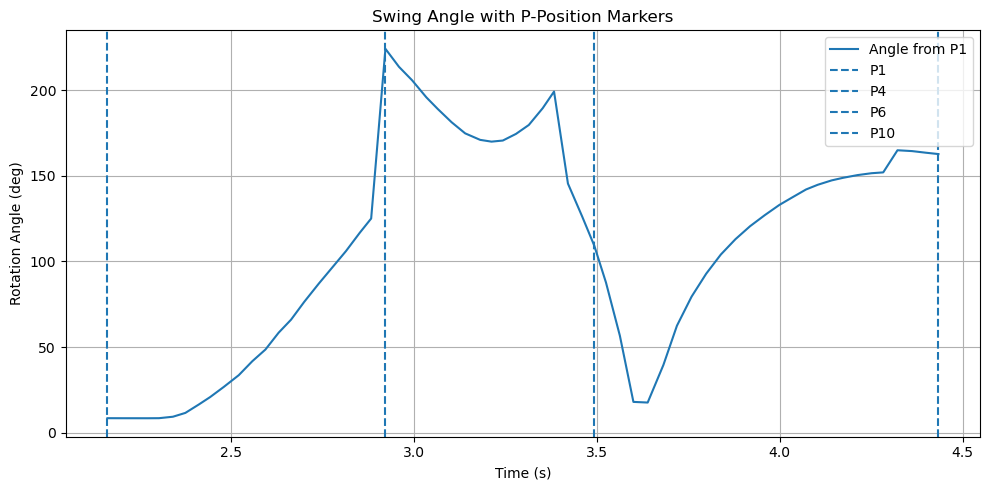

In [11]:
# Step 11: Plot swing phases on gyro graph

plt.figure(figsize=(10, 5))
plt.plot(swing_df["time_s"], swing_df["angle_deg"], label="Angle from P1")

plt.axvline(swing_df.loc[p1_idx, "time_s"], linestyle="--", label="P1")
plt.axvline(swing_df.loc[p4_idx, "time_s"], linestyle="--", label="P4")

if p6_idx is not None:
    plt.axvline(swing_df.loc[p6_idx, "time_s"], linestyle="--", label="P6")

plt.axvline(swing_df.loc[p10_idx, "time_s"], linestyle="--", label="P10")

plt.xlabel("Time (s)")
plt.ylabel("Rotation Angle (deg)")
plt.title("Swing Angle with P-Position Markers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

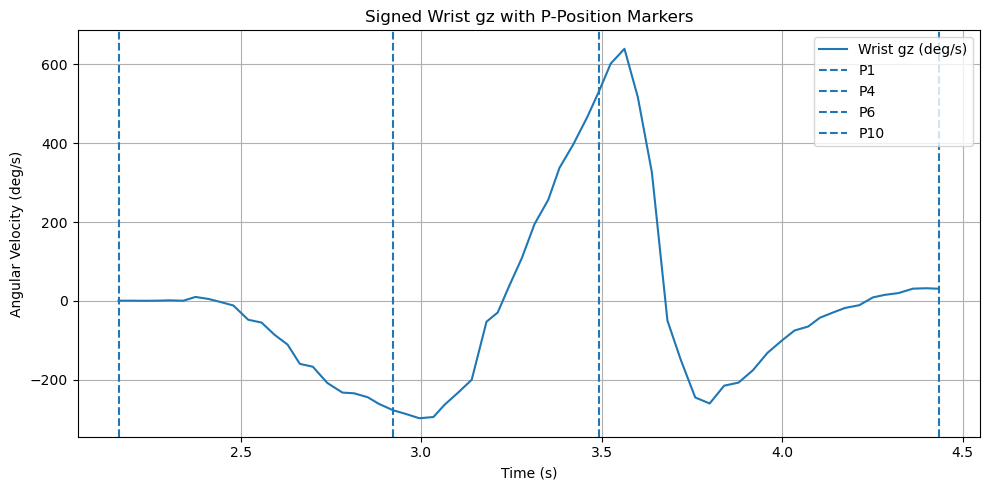

In [20]:
# Step 11.5: Plot signed wrist gz in deg/s with P-position markers

swing_df["gz_deg_s"] = np.degrees(swing_df["gz"])

plt.figure(figsize=(10, 5))
plt.plot(swing_df["time_s"], swing_df["gz_deg_s"], label="Wrist gz (deg/s)")

plt.axvline(swing_df.loc[p1_idx, "time_s"], linestyle="--", label="P1")
plt.axvline(swing_df.loc[p4_idx, "time_s"], linestyle="--", label="P4")

if p6_idx is not None:
    plt.axvline(swing_df.loc[p6_idx, "time_s"], linestyle="--", label="P6")

plt.axvline(swing_df.loc[p10_idx, "time_s"], linestyle="--", label="P10")

plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (deg/s)")
plt.title("Signed Wrist gz with P-Position Markers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

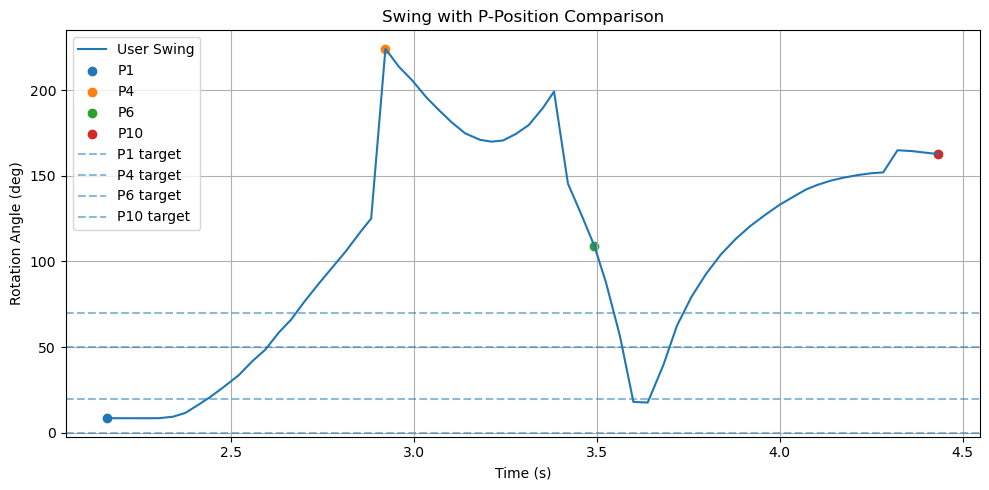

In [13]:
# Step 12: Plot swing with P-position targets

plt.figure(figsize=(10, 5))
plt.plot(swing_df["time_s"], swing_df["angle_deg"], label="User Swing")

# Plot P checkpoints
plt.scatter(swing_df.loc[p1_idx, "time_s"], swing_df.loc[p1_idx, "angle_deg"], label="P1")
plt.scatter(swing_df.loc[p4_idx, "time_s"], swing_df.loc[p4_idx, "angle_deg"], label="P4")

if p6_idx is not None:
    plt.scatter(swing_df.loc[p6_idx, "time_s"], swing_df.loc[p6_idx, "angle_deg"], label="P6")

plt.scatter(swing_df.loc[p10_idx, "time_s"], swing_df.loc[p10_idx, "angle_deg"], label="P10")

# Plot target angles as horizontal reference lines
for p, data in P_TARGETS.items():
    plt.axhline(data["angle"], linestyle="--", alpha=0.5, label=f"{p} target")

plt.xlabel("Time (s)")
plt.ylabel("Rotation Angle (deg)")
plt.title("Swing with P-Position Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

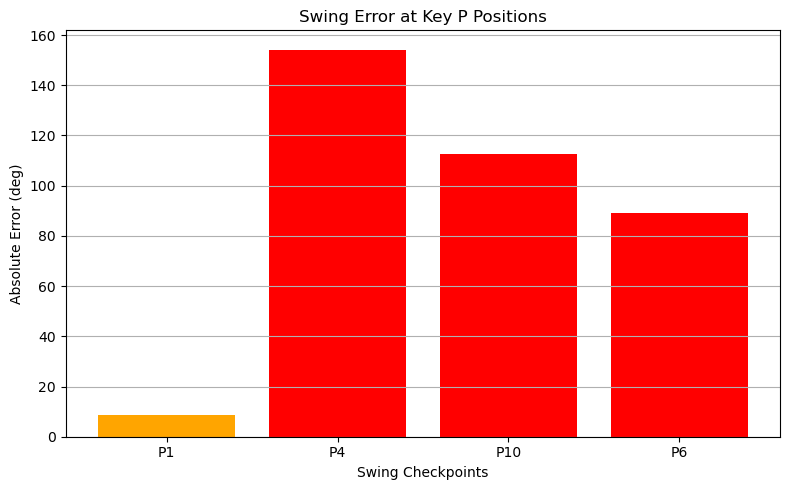

In [14]:
# Step 13: Plot checkpoint errors

p_labels = []
p_error_vals = []

for p, err in p_errors.items():
    p_labels.append(p)
    p_error_vals.append(abs(err))

colors = []
for err in p_error_vals:
    if err < 5:
        colors.append("green")
    elif err < 10:
        colors.append("orange")
    else:
        colors.append("red")

plt.figure(figsize=(8, 5))
plt.bar(p_labels, p_error_vals, color=colors)

plt.xlabel("Swing Checkpoints")
plt.ylabel("Absolute Error (deg)")
plt.title("Swing Error at Key P Positions")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [15]:
# Step 14: Print haptic preview (checkpoint-based)

print("\nHaptic preview (by P position):\n")

for p, err in p_errors.items():
    measured = None
    
    if p == "P1":
        measured = swing_df.loc[p1_idx, "angle_deg"]
    elif p == "P4":
        measured = swing_df.loc[p4_idx, "angle_deg"]
    elif p == "P6" and p6_idx is not None:
        measured = swing_df.loc[p6_idx, "angle_deg"]
    elif p == "P10":
        measured = swing_df.loc[p10_idx, "angle_deg"]

    target = P_TARGETS[p]["angle"]
    error = err
    haptic = haptic_level(abs(error))

    print(f"{p}:")
    print(f"  Measured Angle: {measured:.2f} deg")
    print(f"  Target Angle:   {target:.2f} deg")
    print(f"  Error:          {error:.2f} deg")
    print(f"  Haptic Level:   {haptic}")


Haptic preview (by P position):

P1:
  Measured Angle: 8.52 deg
  Target Angle:   0.00 deg
  Error:          8.52 deg
  Haptic Level:   1
P4:
  Measured Angle: 224.16 deg
  Target Angle:   70.00 deg
  Error:          154.16 deg
  Haptic Level:   2
P10:
  Measured Angle: 162.71 deg
  Target Angle:   50.00 deg
  Error:          112.71 deg
  Haptic Level:   2
P6:
  Measured Angle: 109.24 deg
  Target Angle:   20.00 deg
  Error:          89.24 deg
  Haptic Level:   2
